# Multidimensional Data Visualisation — London Air Quality

Three direct visualisation methods:
1. **Parallel Coordinates** — all dimensions as parallel axes, each record as a polyline
2. *(next)*
3. *(next)*

Reusable: swap `CONFIG` to apply to a different dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Change these to reuse with another dataset.

CONFIG = {
    # Data
    'csv_path'   : 'data/2_unscaled/unscaled.csv',
    'date_col'   : 'date',

    # Which numeric dimensions to visualise
    'features'   : ['CO', 'O3', 'NO', 'NO2', 'PM10', 'PM2.5', 'wind_speed', 'temp'],

    # Target column — split into Low/Medium/High tertiles for colour grouping
    'target_col' : 'PM2.5',
    'color_by'   : 'pm25_level',
    'color_map'  : {
        'Low'    : '#4e91d9',
        'Medium' : '#f4a261',
        'High'   : '#d62728',
    },
}

In [3]:
# ── PIPELINE FUNCTIONS ────────────────────────────────────────────────────────

def load_data(csv_path, date_col):
    return pd.read_csv(csv_path, parse_dates=[date_col])


def daily_means(df, date_col, features):
    """Aggregate hourly readings to daily means, drop days with any NaN feature."""
    return (
        df.groupby(df[date_col].dt.date)[features]
        .mean()
        .dropna()
        .reset_index(drop=True)
    )


def add_pm25_level(df, target_col):
    """Bucket target_col into Low / Medium / High tertiles."""
    return df.assign(
        pm25_level=pd.qcut(df[target_col], q=3, labels=['Low', 'Medium', 'High'])
    )


def prepare(df, *, features, target_col, date_col, **_):
    return (
        df
        .pipe(daily_means, date_col=date_col, features=features)
        .pipe(add_pm25_level, target_col=target_col)
        .reset_index(drop=True)
    )


def minmax_normalize(df, features):
    """Min-max scale each feature to [0, 1] independently (for plotting only)."""
    normed = df[features].copy()
    for f in features:
        lo, hi = df[f].min(), df[f].max()
        normed[f] = (df[f] - lo) / (hi - lo)
    return normed

## Method 1 — Parallel Coordinates

Each dimension is a vertical axis (min-max normalised to make scales comparable).  
Each record is drawn as a polyline crossing all axes.  
Lines are coloured by **PM2.5 level** (Low / Medium / High tertiles).

**Kaip skaityti:** jei vienos spalvos linijos susikaupia ties tam tikra ašimi — tas feature stipriai nulemia PM2.5 lygį.

In [4]:
def plot_parallel_coordinates(df, *, features, color_by, color_map, title='Parallel Coordinates', alpha=0.04, linewidth=0.6):
    """
    Parameters
    ----------
    df        : DataFrame with `features` columns + `color_by` column
    features  : list of column names to use as axes
    color_by  : categorical column for colour grouping (or None)
    color_map : dict {category: hex_color}
    """
    normed = minmax_normalize(df, features)
    x = np.arange(len(features))

    fig, ax = plt.subplots(figsize=(14, 6))

    categories = color_map.keys() if color_by else [None]
    for cat in categories:
        mask   = (df[color_by] == cat) if color_by else slice(None)
        values = normed[mask][features].values          # (n_samples, n_features)
        color  = color_map.get(cat, '#888888') if color_by else '#4e91d9'

        if len(values) == 0:
            continue

        # Build one LineCollection per category — much faster than a loop
        segments = [np.column_stack([x, row]) for row in values]
        lc = LineCollection(segments, colors=color, alpha=alpha, linewidths=linewidth)
        ax.add_collection(lc)

    # Axis decoration
    ax.set_xlim(-0.5, len(features) - 0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(features, fontsize=11)
    ax.set_ylabel('Normalised value  [0 – 1]', fontsize=10)
    ax.set_title(title, fontsize=13, pad=10)
    ax.grid(axis='x', color='#cccccc', linewidth=0.8)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Draw vertical axis lines explicitly
    for xi in x:
        ax.axvline(xi, color='#555555', linewidth=1.2, zorder=3)

    # Legend
    if color_by:
        handles = [plt.Line2D([0], [0], color=c, linewidth=2.5, label=k)
                   for k, c in color_map.items()]
        ax.legend(handles=handles, title=color_by.capitalize(),
                  loc='upper right', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    return fig

Dienų po agregacijos: 4131
PM2.5 tertilių ribos:
              min    max
pm25_level              
Low          1.33   9.95
Medium       9.95  15.47
High        15.48  95.77


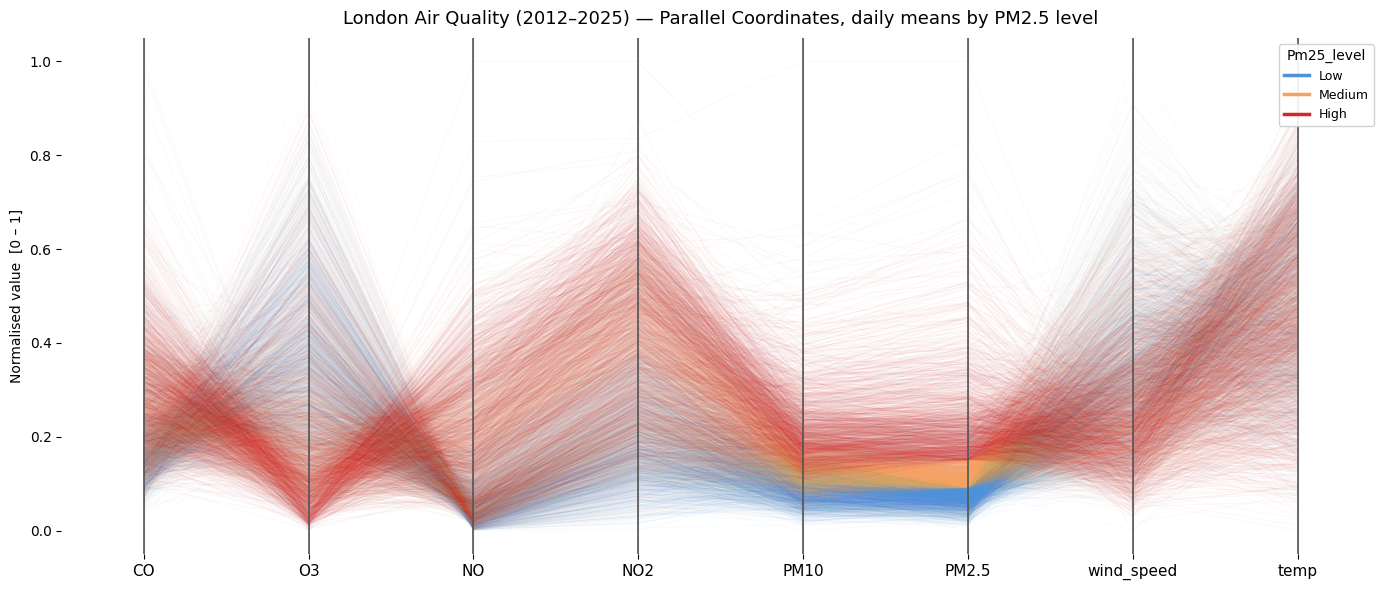

In [5]:
# ── RUN ───────────────────────────────────────────────────────────────────────

df_raw  = load_data(CONFIG['csv_path'], CONFIG['date_col'])
df_plot = prepare(df_raw, **CONFIG)

print(f"Dienų po agregacijos: {len(df_plot)}")
print(f"PM2.5 tertilių ribos:\n{df_plot.groupby('pm25_level')['PM2.5'].agg(['min','max']).round(2)}")

fig = plot_parallel_coordinates(
    df_plot,
    features  = CONFIG['features'],
    color_by  = CONFIG['color_by'],
    color_map = CONFIG['color_map'],
    title     = 'London Air Quality (2012–2025) — Parallel Coordinates, daily means by PM2.5 level',
)
plt.show()

### Observations

*(fill in after seeing the plot)*

- **PM10 ašis** — raudonos (High PM2.5) linijos ryškiai kaupiasi viršuje, mėlynos (Low) apačioje. Tai stipriausias vizualus atsiskyrimas → PM10 yra dominuojantis PM2.5 prediktorius (r = 0.87).
- **NO ir NO2 ašys** — High PM2.5 linijos linkusios būti aukščiau, tačiau atsiskyrimas silpnesnis nei PM10. Tai atspindi vidutinę koreliaciją (~0.48).
- **wind_speed ašis** — High PM2.5 linijos kaupiasi žemiau (mažas vėjas), Low — aukščiau. Vėjas sklaido daleles.
- **O3 ašis** — atvirkštinis ryšys: High PM2.5 linijos žemiau O3 ašyje.
- **temp** — mažiausias vizualus atsiskyrimas tarp grupių → silpniausias PM2.5 prediktorius.